##### 1. Load Libraries

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

##### 2. Load and Add Target Columns (normalized from preprocessing notebook)
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [6]:
# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO",
    "STAPH": "10:0 | Staph : PAO",
    "PAO1": "0:10 | Staph : PAO", 
    "Corn" : "Corn", 
    "E.coli" : "E.coli", 
    "FAE" : "FAE",
    "Malt" : "Malt"
}

def read_all_csvs_to_df(folder_paths):
    if isinstance(folder_paths, (str, os.PathLike)):
        folder_paths = [folder_paths]

    file_paths = []
    for folder_path in folder_paths:
        file_paths.extend(
            os.path.join(folder_path, file_name)
            for file_name in sorted(os.listdir(folder_path))
            if file_name.endswith(".csv")
        )

    if not file_paths:
        raise ValueError(f"No CSV files found in folders: {folder_paths}")

    loaded_files = []
    for file_path in file_paths:
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path, header=None)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        loaded_files.append((file_name, df, target_value))

    min_feature_cols = min(df.shape[1] for _, df, _ in loaded_files)
    dataframes = []

    for i, (file_name, df, target_value) in enumerate(loaded_files):
        if df.shape[1] > min_feature_cols:
            print(f"Trimming {file_name} from {df.shape[1]} to {min_feature_cols} spectral columns.")
            df = df.iloc[:, :min_feature_cols]

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        df = df.copy()
        df["target"] = target_value
        dataframes.append(df)

    combined_df = pd.concat(dataframes, ignore_index=True).copy()

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_paths = [
    os.path.join("..", "data", "mixed_ratio"),
    os.path.join("..", "data", "six_single_species")
]
df = read_all_csvs_to_df(folder_paths)


Trimming g_mixed_1-9_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_3_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_1-9_S-P_4_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_3_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_3-7_S-P_4_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_5-5_S-P_1_spectra_normalized_outlier_corrected.csv from 389 to 388 spectral columns.
Trimming g_mixed_5-5_S-P_2_spectra_normalized_outlier_corrected.csv from 389 to 38

##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [7]:
def label_data(dataframe):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df

clean_df = label_data(df)

#for testing
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Implement SVD

In [8]:
def _resolve_metadata_path(filename):
    candidate_paths = [
        os.path.join(os.getcwd(), filename),
        os.path.join(os.getcwd(), "Analysis", "SVD", filename),
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not locate {filename} from the current working directory.")


def run_svd(dataframe, target_col="target_encoded", n_components=10):
    if target_col not in dataframe.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    feature_cols = [col for col in dataframe.columns if col != target_col]
    if not feature_cols:
        raise ValueError("No feature columns were found for SVD.")

    X = dataframe[feature_cols].to_numpy(dtype=float)
    y = dataframe[target_col].to_numpy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    U, singular_values, Vt = np.linalg.svd(X_scaled, full_matrices=False)
    n_components = min(n_components, len(singular_values))

    U = U[:, :n_components]
    singular_values = singular_values[:n_components]
    Vt = Vt[:n_components, :]
    scores = U * singular_values

    all_singular_values = np.linalg.svd(X_scaled, full_matrices=False, compute_uv=False)
    explained_variance_ratio = (singular_values ** 2) / np.sum(all_singular_values ** 2)

    with open(_resolve_metadata_path("target_encoding_map.json"), "r") as f:
        target_map_raw = json.load(f)
    target_map = {v: k for k, v in target_map_raw.items()}

    with open(_resolve_metadata_path("feature_map.json"), "r") as f:
        feature_map_raw = json.load(f)
    wavenumbers = np.array([float(feature_map_raw[str(col)]) for col in feature_cols])

    scores_df = pd.DataFrame(
        scores,
        columns=[f"SV{i+1}" for i in range(scores.shape[1])]
    )
    scores_df[target_col] = y
    scores_df["target_label"] = [target_map[val] for val in y]

    print(f"SVD fitted with {n_components} components.")
    print(f"Spectral matrix shape: {X.shape}")
    print("Explained variance by singular vector:")
    for i, var in enumerate(explained_variance_ratio[:5], start=1):
        print(f"  SV{i}: {var * 100:.2f}%")
    if len(explained_variance_ratio) >= 2:
        print(f"  SV1+SV2 combined: {explained_variance_ratio[:2].sum() * 100:.2f}%")

    return {
        "scaler": scaler,
        "feature_columns": feature_cols,
        "wavenumbers": wavenumbers,
        "scores": scores,
        "scores_df": scores_df,
        "singular_values": singular_values,
        "right_singular_vectors": Vt,
        "explained_variance_ratio": explained_variance_ratio,
        "targets": y,
        "target_map": target_map,
        "target_col": target_col,
    }


svd_results = run_svd(clean_df, target_col="target_encoded", n_components=10)
svd_df = svd_results["scores_df"]


SVD fitted with 10 components.
Spectral matrix shape: (64130, 388)
Explained variance by singular vector:
  SV1: 41.47%
  SV2: 15.23%
  SV3: 10.36%
  SV4: 6.33%
  SV5: 2.87%
  SV1+SV2 combined: 56.69%


##### 5. Visualize the SVD

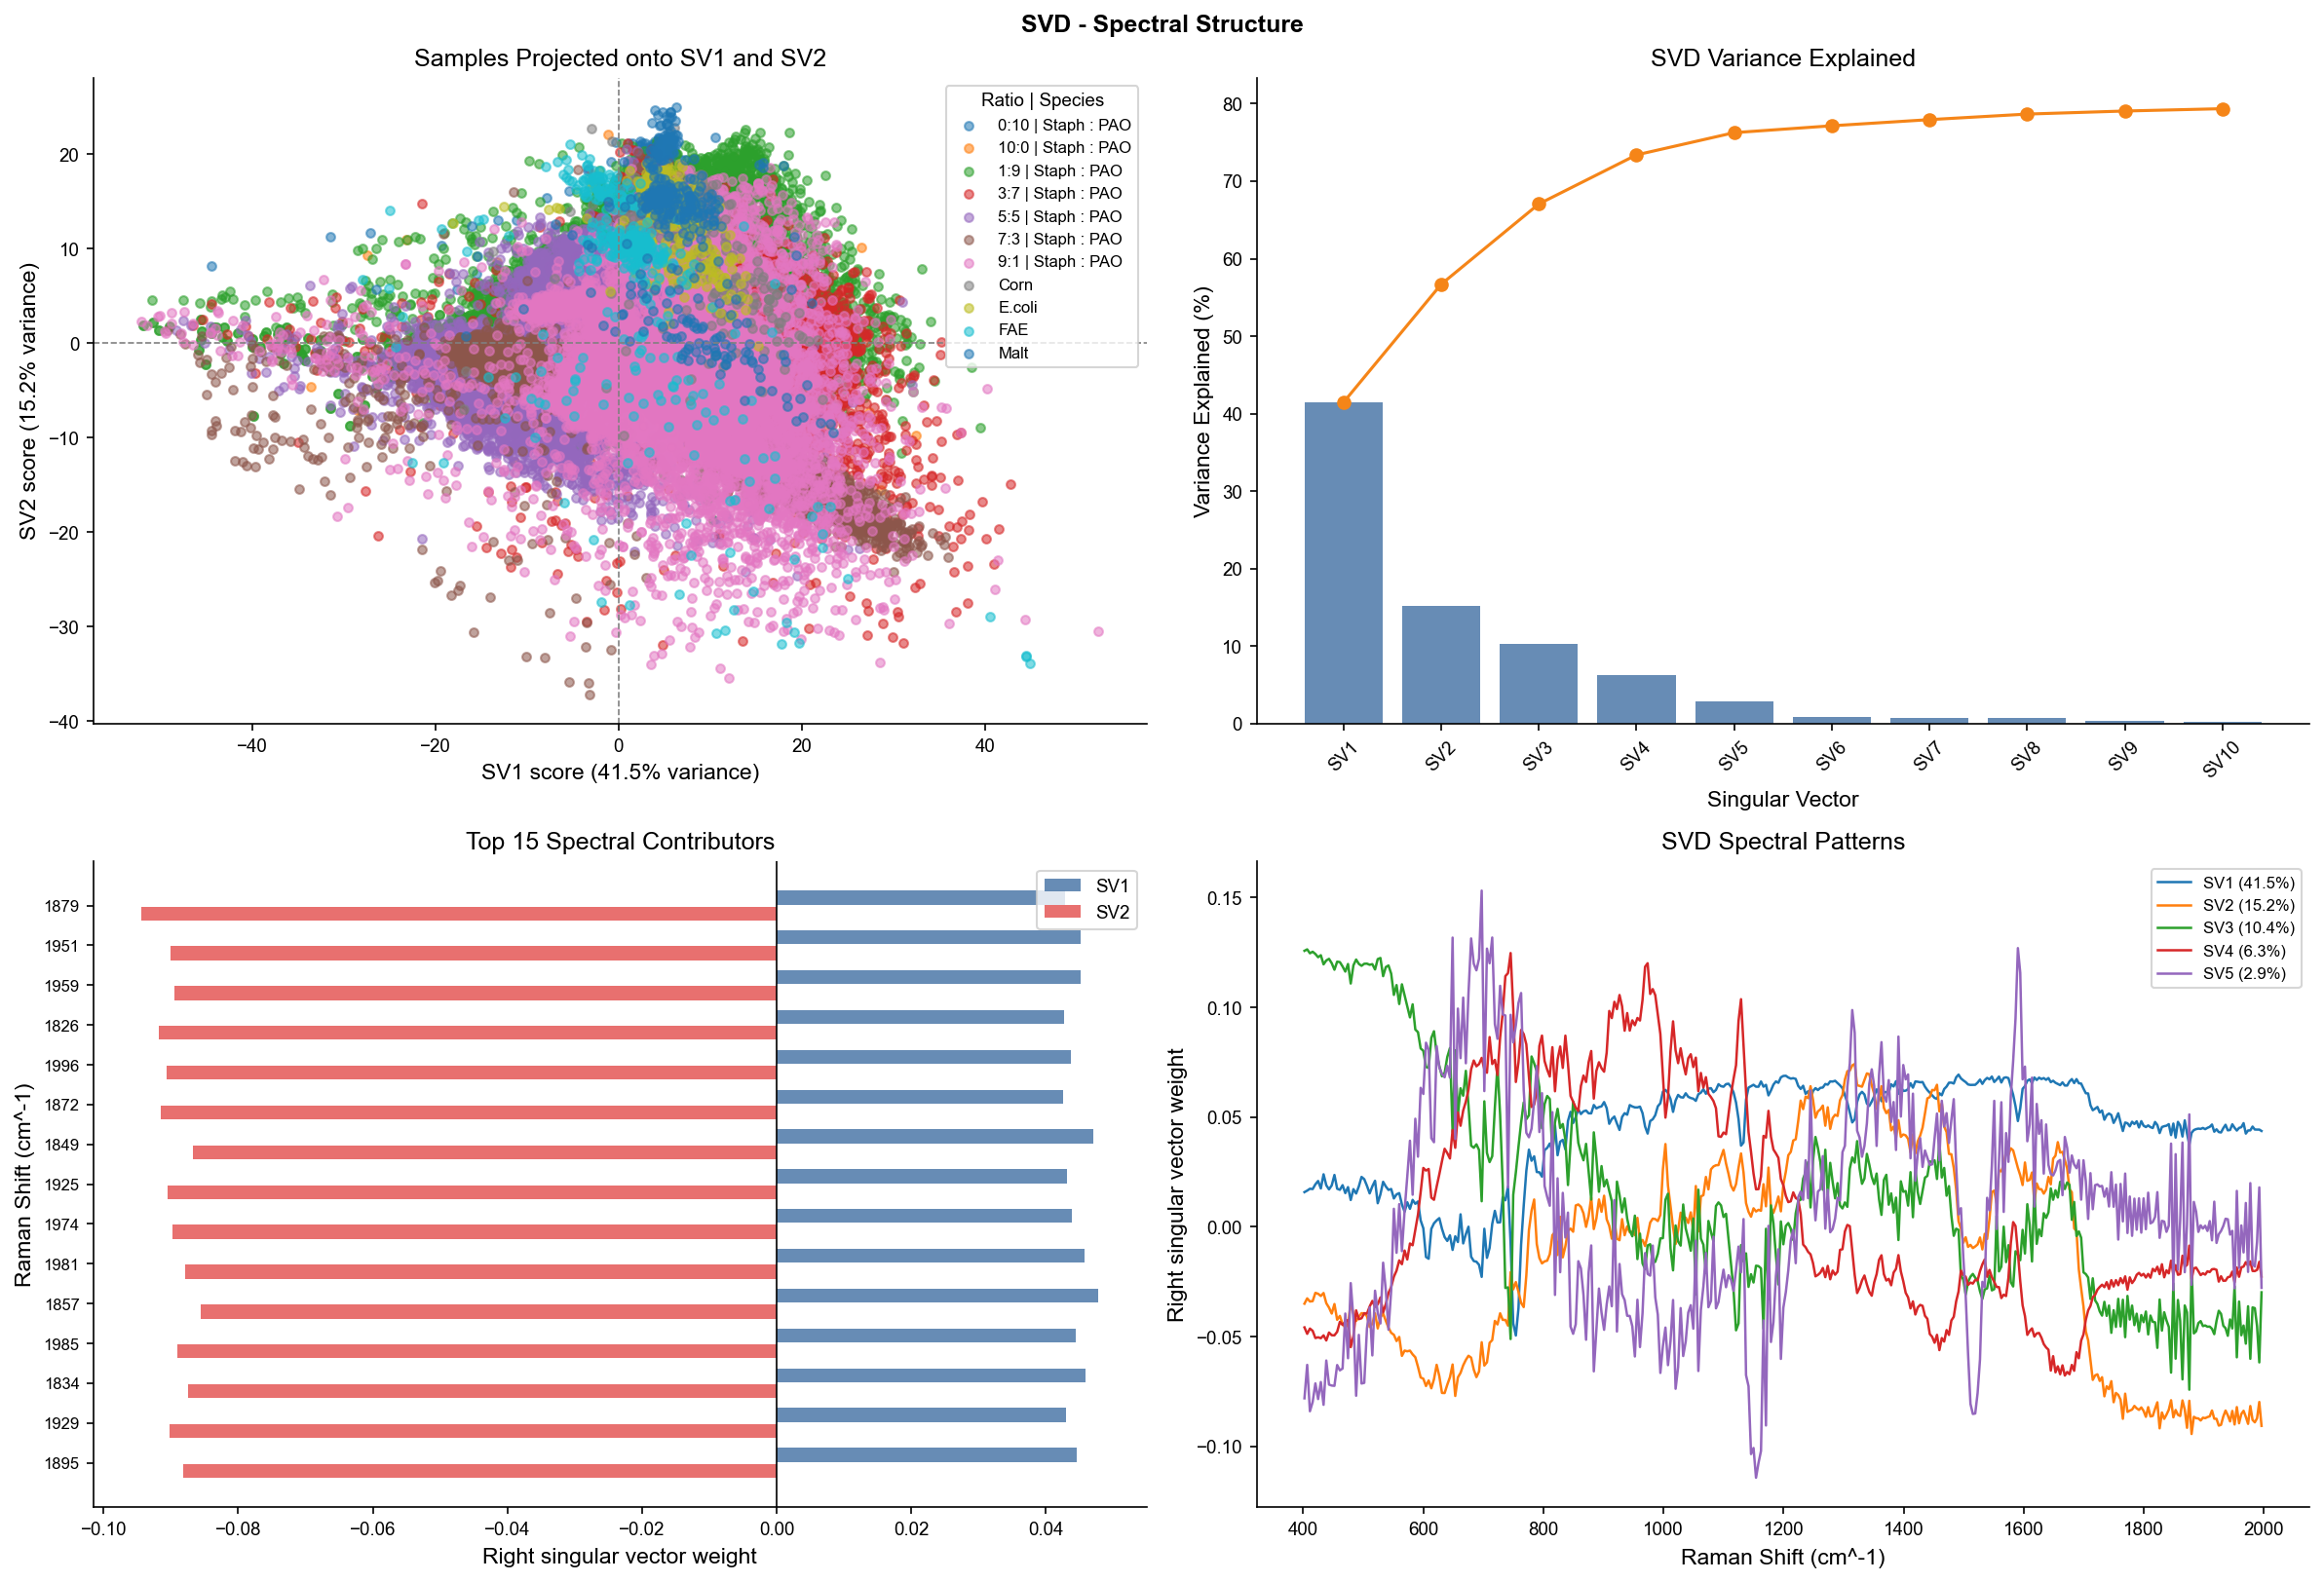

In [9]:
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})

scores_df = svd_results["scores_df"]
wavenumbers = svd_results["wavenumbers"]
right_singular_vectors = svd_results["right_singular_vectors"]
explained_variance_ratio = svd_results["explained_variance_ratio"]
target_col = svd_results["target_col"]
target_map = svd_results["target_map"]

unique_groups = sorted(scores_df[target_col].unique())
palette = sns.color_palette("tab10", n_colors=len(unique_groups))
group_colors = {grp: palette[i] for i, grp in enumerate(unique_groups)}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

ax = axes[0, 0]
for grp in unique_groups:
    grp_df = scores_df[scores_df[target_col] == grp]
    ax.scatter(
        grp_df["SV1"],
        grp_df["SV2"],
        s=18,
        alpha=0.55,
        color=group_colors[grp],
        label=target_map[grp],
    )
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"SV1 score ({explained_variance_ratio[0] * 100:.1f}% variance)")
ax.set_ylabel(f"SV2 score ({explained_variance_ratio[1] * 100:.1f}% variance)")
ax.set_title("Samples Projected onto SV1 and SV2")
ax.legend(title="Ratio | Species", fontsize=8, title_fontsize=9, loc="best")

ax = axes[0, 1]
component_names = [f"SV{i+1}" for i in range(len(explained_variance_ratio))]
ax.bar(component_names, explained_variance_ratio * 100, color="#4C78A8", alpha=0.85)
ax.plot(component_names, np.cumsum(explained_variance_ratio) * 100, color="#F58518", marker="o", linewidth=1.5)
ax.set_xlabel("Singular Vector")
ax.set_ylabel("Variance Explained (%)")
ax.set_title("SVD Variance Explained")
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 0]
top_n = min(15, right_singular_vectors.shape[1])
combined_weight = np.abs(right_singular_vectors[0]) + np.abs(right_singular_vectors[1])
top_idx = np.argsort(combined_weight)[::-1][:top_n]
ypos = np.arange(top_n)
ax.barh(ypos - 0.2, right_singular_vectors[0, top_idx], height=0.35, color="#4C78A8", alpha=0.85, label="SV1")
ax.barh(ypos + 0.2, right_singular_vectors[1, top_idx], height=0.35, color="#E45756", alpha=0.85, label="SV2")
ax.set_yticks(ypos)
ax.set_yticklabels([f"{wavenumbers[i]:.0f}" for i in top_idx], fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Right singular vector weight")
ax.set_ylabel("Raman Shift (cm^-1)")
ax.set_title(f"Top {top_n} Spectral Contributors")
ax.legend(fontsize=9)
ax.invert_yaxis()

ax = axes[1, 1]
n_plot = min(5, right_singular_vectors.shape[0])
for i in range(n_plot):
    ax.plot(
        wavenumbers,
        right_singular_vectors[i],
        linewidth=1.2,
        label=f"SV{i+1} ({explained_variance_ratio[i] * 100:.1f}%)"
    )
ax.set_xlabel("Raman Shift (cm^-1)")
ax.set_ylabel("Right singular vector weight")
ax.set_title("SVD Spectral Patterns")
ax.legend(fontsize=8, loc="best")

plt.suptitle("SVD - Spectral Structure", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("svd_visual.png", dpi=300, bbox_inches="tight")
plt.show()
